<a href="https://colab.research.google.com/github/keewiiwee/ev-charging-analysis/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A7%88%EC%9D%B4%EB%8B%9D_%EC%84%9C%EC%9A%B8%EC%8B%9C_%EC%A0%84%EA%B8%B0%EC%B0%A8_%EC%B6%A9%EC%A0%84%EC%9D%B8%ED%94%84%EB%9D%BC_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#서울시 자치구별 전기차 보급률과 충전 인프라 분석

## 분석 목적

서울시 자치구별 전기차 등록 현황과 충전 인프라 현황을 분석하고,
전기차 보급 수준에 비해 충전 인프라가 부족한 지역을 도출하고자 한다.

## 데이터 수집

1. 서울시 자치구별 전기차 등록 현황(2017~2022)
2. 서울시 주민등록인구 현황
3. 한국환경공단 전기차 충전소 Open API

In [12]:
!apt-get install -y fonts-nanum
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.


In [13]:
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.rc('axes', unicode_minus = False)

## 데이터 전처리

전기차 등록 데이터에서 연도를 추출하고,
자치구별 전기차 등록 대수를 집계하였다.

In [14]:
from google.colab import files
uploaded = files.upload()

Saving 서울시 자치구별 전기차 용도별 등록현황(2017~2022년).csv to 서울시 자치구별 전기차 용도별 등록현황(2017~2022년) (6).csv


In [15]:
import pandas as pd

df = pd.read_csv(
    '서울시 자치구별 전기차 용도별 등록현황(2017~2022년).csv',
    encoding='cp949'
)

df.head()

,연월별,시군구별,연료별,용도별,승 용,승 합,화 물,특 수,계
0,2017-12-31,종로구,전기,비사업용,73,0,2,0,75
1,2017-12-31,중 구,전기,비사업용,106,1,2,0,109
2,2017-12-31,중 구,전기,사업용,1,0,0,0,1
3,2017-12-31,용산구,전기,비사업용,67,0,0,0,67
4,2017-12-31,성동구,전기,비사업용,85,0,1,0,86


In [16]:
ev = df.copy()

ev['연도'] = ev['연월별'].astype(str).str[:4]

ev.head()

,연월별,시군구별,연료별,용도별,승 용,승 합,화 물,특 수,계,연도
0,2017-12-31,종로구,전기,비사업용,73,0,2,0,75,2017
1,2017-12-31,중 구,전기,비사업용,106,1,2,0,109,2017
2,2017-12-31,중 구,전기,사업용,1,0,0,0,1,2017
3,2017-12-31,용산구,전기,비사업용,67,0,0,0,67,2017
4,2017-12-31,성동구,전기,비사업용,85,0,1,0,86,2017


연도별 전기차 등록대수

In [17]:
year_sum = ev.groupby('연도')['계'].sum()

year_sum

,계
연도,
2017,4797
2018,9564
2019,14952
2020,23393
2021,40564
2022,49590


## 연도별 전기차 증가 추이

서울시 전기차 등록 대수의 변화 추이를 확인한다.

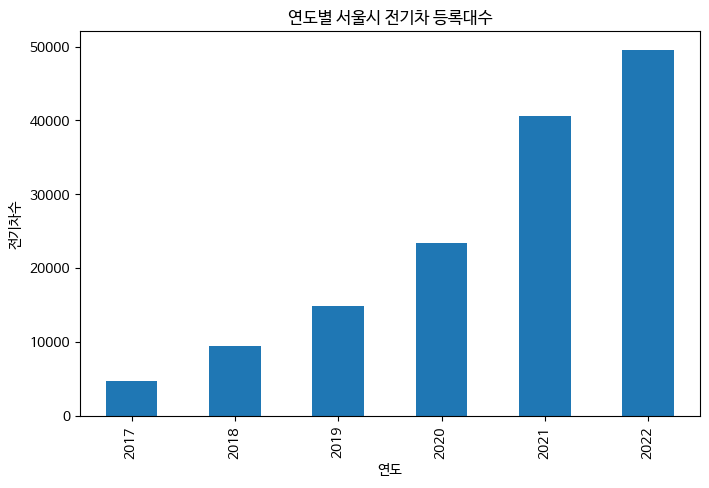

In [18]:
import matplotlib.pyplot as plt

year_sum.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('연도별 서울시 전기차 등록대수')
plt.xlabel('연도')
plt.ylabel('전기차수')

plt.show()

2022년 데이터만 추출

In [19]:
ev_2022 = ev[
    ev['연도'] == '2022'
].copy()

ev_2022.head()

,연월별,시군구별,연료별,용도별,승 용,승 합,화 물,특 수,계,연도
242,2022-07-31,종로구,전기,비사업용,549,1,65,0,615,2022
243,2022-07-31,종로구,전기,사업용,34,10,33,0,77,2022
244,2022-07-31,중 구,전기,비사업용,647,4,59,0,710,2022
245,2022-07-31,중 구,전기,사업용,277,0,72,0,349,2022
246,2022-07-31,용산구,전기,비사업용,773,1,74,0,848,2022


자치구별 집계

In [20]:
ev_group = (
    ev_2022
    .groupby('시군구별')['계']
    .sum()
    .reset_index()
)

ev_group.columns = [
    '자치구',
    '전기차수'
]

ev_group.head()

,자치구,전기차수
0,강남구,13703
1,강동구,1720
2,강북구,724
3,강서구,2317
4,관악구,1052


Top10

In [21]:
top10_ev = ev_group.sort_values(
    '전기차수',
    ascending=False
).head(10)

top10_ev

,자치구,전기차수
0,강남구,13703
6,구로구,4210
14,서초구,3880
19,영등포구,2679
17,송파구,2540
3,강서구,2317
1,강동구,1720
15,성동구,1675
12,마포구,1390
18,양천구,1376


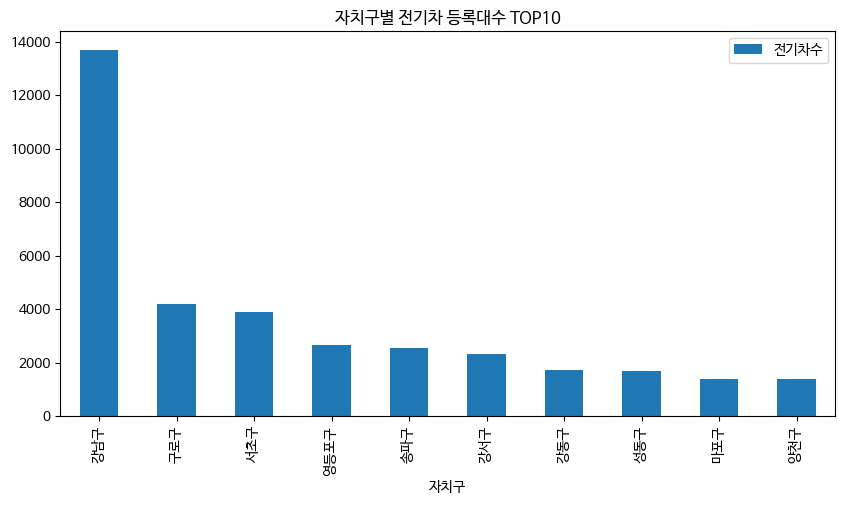

In [22]:
top10_ev.plot(
    x='자치구',
    y='전기차수',
    kind='bar',
    figsize=(10,5)
)

plt.title('자치구별 전기차 등록대수 TOP10')

plt.show()

## 전기차 보급률 산출

자치구별 인구수를 활용하여
인구 1000명당 전기차 수를 계산하였다.

서울시 인구데이터(2017-2022)

In [23]:
pop = pd.read_csv(
    '/content/201712_202212_주민등록인구및세대현황_연간.csv',
    encoding='cp949'
)

pop.head()

,행정구역,2017년_총인구수,2017년_세대수,2017년_세대당 인구,2017년_남자 인구수,2017년_여자 인구수,2017년_남여 비율,2018년_총인구수,2018년_세대수,2018년_세대당 인구,...,2021년_세대당 인구,2021년_남자 인구수,2021년_여자 인구수,2021년_남여 비율,2022년_총인구수,2022년_세대수,2022년_세대당 인구,2022년_남자 인구수,2022년_여자 인구수,2022년_남여 비율
0,서울특별시 (1100000000),"9,857,426","4,220,082",2.34,"4,830,206","5,027,220",0.96,"9,765,623","4,263,868",2.29,...,2.15,"4,618,040","4,891,418",0.94,"9,428,372","4,446,296",2.12,"4,570,048","4,858,324",0.94
1,서울특별시 서울특별시 종로구 (1111000000),"154,770","73,594",2.10,"75,967","78,803",0.96,"153,065","73,735",2.08,...,1.97,"70,183","74,500",0.94,"141,379","72,524",1.95,"68,395","72,984",0.94
2,서울특별시 서울특별시 중구 (1114000000),"125,709","60,412",2.08,"62,253","63,456",0.98,"125,725","61,502",2.04,...,1.93,"59,630","62,869",0.95,"120,437","63,139",1.91,"58,563","61,874",0.95
3,서울특별시 서울특별시 용산구 (1117000000),"229,161","107,666",2.13,"110,878","118,283",0.94,"228,999","108,974",2.10,...,2.01,"107,210","115,743",0.93,"218,650","109,805",1.99,"105,087","113,563",0.93
4,서울특별시 서울특별시 성동구 (1120000000),"304,808","132,902",2.29,"150,368","154,440",0.97,"308,221","137,209",2.25,...,2.13,"139,380","146,610",0.95,"281,000","133,305",2.11,"136,633","144,367",0.95


In [24]:
pop = pop.iloc[1:].copy()

In [25]:
pop['자치구'] = pop['행정구역'].str.extract(r'(종로구|중구|용산구|성동구|광진구|동대문구|중랑구|성북구|강북구|도봉구|노원구|은평구|서대문구|마포구|양천구|강서구|구로구|금천구|영등포구|동작구|관악구|서초구|강남구|송파구|강동구)')

In [26]:
pop = pop[['자치구', '2022년_총인구수']]

pop.columns = [
    '자치구',
    '인구수'
]

pop.head()

,자치구,인구수
1,종로구,"141,379"
2,중구,"120,437"
3,용산구,"218,650"
4,성동구,"281,000"
5,광진구,"337,416"


In [27]:
pop['인구수'] = (
    pop['인구수']
    .astype(str)
    .str.replace(',', '')
    .astype(int)
)

In [28]:
final_df = pd.merge(
    ev_group,
    pop,
    on='자치구',
    how='inner'
)

final_df.head()

,자치구,전기차수,인구수
0,강남구,13703,529102
1,강동구,1720,460067
2,강북구,724,293660
3,강서구,2317,569166
4,관악구,1052,486752


In [29]:
final_df['천명당전기차수'] = (
    final_df['전기차수']
    /
    final_df['인구수']
    * 1000
)

In [30]:
final_df.sort_values(
    '천명당전기차수',
    ascending=False
)

,자치구,전기차수,인구수,천명당전기차수
0,강남구,13703,529102,25.898598
6,구로구,4210,395315,10.649735
14,서초구,3880,404325,9.596241
19,영등포구,2679,375675,7.131164
15,성동구,1675,281000,5.960854
22,종로구,692,141379,4.894645
20,용산구,910,218650,4.161903
3,강서구,2317,569166,4.070869
17,송파구,2540,658801,3.855489
12,마포구,1390,364638,3.812000


## 충전 인프라 분석

한국환경공단 Open API를 활용하여
서울시 충전소 정보를 수집하였다.

In [31]:
import requests
import pandas as pd

service_key = '2deb8e0f7c706ebafa106a414c4234f637567045d1a287f8587e002eafb2b2fc'

In [48]:
url = 'http://apis.data.go.kr/B552584/EvCharger/getChargerInfo'

params = {
    'serviceKey': service_key,
    'pageNo': 1,
    'numOfRows': 9999,
    'zcode': 11,        # 서울특별시
    'dataType': 'JSON'
}

response = requests.get(url, params=params)

data = response.json()

데이터 프레임 생성

In [33]:
charger = pd.DataFrame(data['items']['item'])

charger.head()

,statNm,statId,chgerId,chgerType,addr,addrDetail,location,useTime,lat,lng,...,note,limitYn,limitDetail,delYn,delDetail,trafficYn,year,floorNum,floorType,maker
0,낙성대동주민센터,ME174013,01,06,서울특별시 관악구 낙성대로4가길 5,null,null,24시간 이용가능,37.476296,126.9583876,...,,N,,N,,N,2017,1,F,시그넷
1,서울추모공원,ME174027,01,06,서울특별시 서초구 양재대로12길 74,1층 입구,null,24시간 이용가능,37.4536062,127.0428005,...,,N,,N,,N,2017,1,F,시그넷
2,롯데마트 송파점,ME174029,01,06,서울특별시 송파구 중대로 80,지하4층 C8,null,24시간 이용가능,37.4918392,127.1178931,...,,N,,N,,N,2017,4,B,시그넷
3,현대자동차 수색대리점,ME174037,01,06,서울특별시 은평구 수색로 342-1,null,null,24시간 이용가능,37.5867665,126.8880299,...,,N,,N,,N,2017,1,F,시그넷
4,태화빌딩,ME174039,01,06,서울특별시 종로구 인사동5길 29,지상주차장,null,24시간 이용가능,37.5718148,126.9850443,...,,N,,N,,N,2017,1,F,시그넷


In [34]:
charger.columns

Index(['statNm', 'statId', 'chgerId', 'chgerType', 'addr', 'addrDetail',
       'location', 'useTime', 'lat', 'lng', 'busiId', 'bnm', 'busiNm',
       'busiCall', 'stat', 'statUpdDt', 'lastTsdt', 'lastTedt', 'nowTsdt',
       'powerType', 'output', 'method', 'zcode', 'zscode', 'kind',
       'kindDetail', 'parkingFree', 'note', 'limitYn', 'limitDetail', 'delYn',
       'delDetail', 'trafficYn', 'year', 'floorNum', 'floorType', 'maker'],
      dtype='object')

자치구 추출

In [35]:
charger['자치구'] = charger['addr'].str.extract(
    r'서울특별시\s+(\S+구)'
)

charger[['addr','자치구']].head()

,addr,자치구
0,서울특별시 관악구 낙성대로4가길 5,관악구
1,서울특별시 서초구 양재대로12길 74,서초구
2,서울특별시 송파구 중대로 80,송파구
3,서울특별시 은평구 수색로 342-1,은평구
4,서울특별시 종로구 인사동5길 29,종로구


In [36]:
charger_group = (
    charger
    .groupby('자치구')
    .size()
    .reset_index(name='충전기수')
)

charger_group.head()

,자치구,충전기수
0,강남구,789
1,강동구,381
2,강북구,142
3,강서구,676
4,관악구,175


In [37]:
final_df2 = pd.merge(
    final_df,
    charger_group,
    on='자치구',
    how='inner'
)

final_df2.head()

,자치구,전기차수,인구수,천명당전기차수,충전기수
0,강남구,13703,529102,25.898598,789
1,강동구,1720,460067,3.738586,381
2,강북구,724,293660,2.465436,142
3,강서구,2317,569166,4.070869,676
4,관악구,1052,486752,2.161265,175


핵심지표

In [38]:
final_df2['충전기당전기차수'] = (
    final_df2['전기차수']
    /
    final_df2['충전기수']
)

In [39]:
final_df2.sort_values(
    '충전기당전기차수',
    ascending=False
)

,자치구,전기차수,인구수,천명당전기차수,충전기수,충전기당전기차수
0,강남구,13703,529102,25.898598,789,17.367554
6,구로구,4210,395315,10.649735,413,10.193705
14,서초구,3880,404325,9.596241,609,6.371100
4,관악구,1052,486752,2.161265,175,6.011429
15,성동구,1675,281000,5.960854,300,5.583333
2,강북구,724,293660,2.465436,142,5.098592
19,영등포구,2679,375675,7.131164,568,4.716549
1,강동구,1720,460067,3.738586,381,4.514436
17,송파구,2540,658801,3.855489,598,4.247492
5,광진구,811,337416,2.403561,196,4.137755


## K-Means 군집분석

전기차 보급률과 충전 인프라 수준을 기준으로
서울시 자치구를 유형별로 분류하였다.

1. 표준화

In [40]:
from sklearn.preprocessing import StandardScaler

X = final_df2[
    ['천명당전기차수',
     '충전기당전기차수']
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

2. 엘보우
//최적 군집 수(k)를 결정하기 위해 Elbow Method 수행

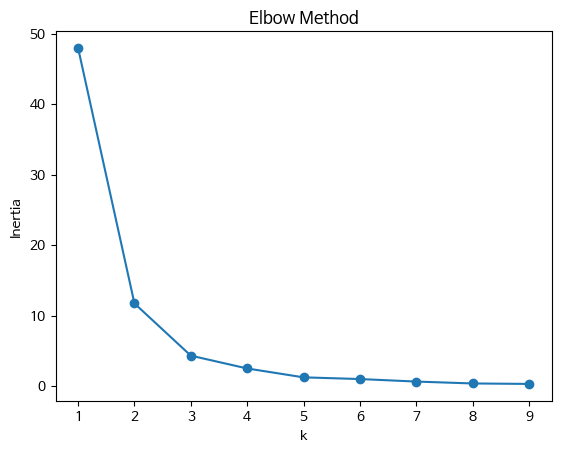

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.plot(
    range(1,10),
    inertia,
    marker='o'
)

plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

3. Elbow Method 결과를 바탕으로 군집 수를 3개로 설정


In [44]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

final_df2['Cluster'] = (
    kmeans.fit_predict(X_scaled)
)

4. 결과 확인

In [45]:
final_df2[
    ['자치구',
     '천명당전기차수',
     '충전기당전기차수',
     'Cluster']
]

,자치구,천명당전기차수,충전기당전기차수,Cluster
0,강남구,25.898598,17.367554,1
1,강동구,3.738586,4.514436,0
2,강북구,2.465436,5.098592,0
3,강서구,4.070869,3.427515,0
4,관악구,2.161265,6.011429,0
5,광진구,2.403561,4.137755,0
6,구로구,10.649735,10.193705,2
7,금천구,3.392237,3.273109,0
8,노원구,2.404047,3.420904,0
9,도봉구,2.627577,3.067416,0


5. 군집분석 결과 시각화

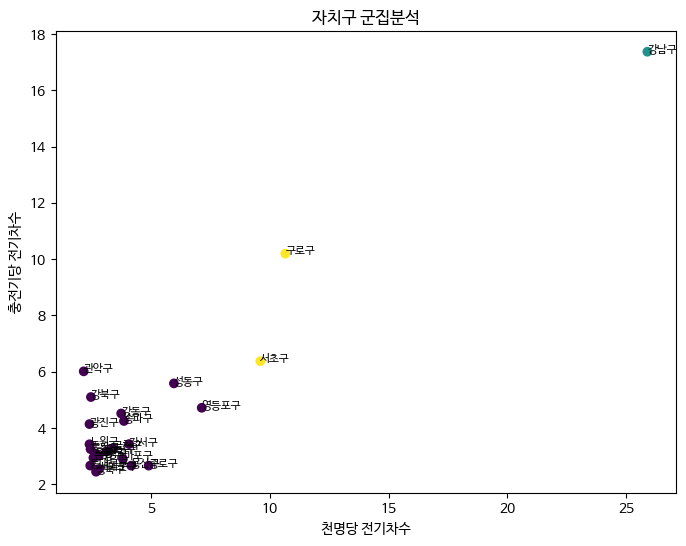

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df2['천명당전기차수'],
    final_df2['충전기당전기차수'],
    c=final_df2['Cluster']
)

plt.xlabel('천명당 전기차수')
plt.ylabel('충전기당 전기차수')

plt.title('자치구 군집분석')

for i in range(len(final_df2)):
    plt.text(
        final_df2['천명당전기차수'].iloc[i],
        final_df2['충전기당전기차수'].iloc[i],
        final_df2['자치구'].iloc[i],
        fontsize=8
    )

plt.show()

## 군집분석 결과

K-Means 군집분석 결과 서울시 자치구는 총 3개의 군집으로 분류되었다.

강남구는 전기차 보급률과 충전 인프라 수준이 모두 매우 높아 독립적인 군집으로 분류되었다.

구로구와 서초구는 전기차 보급률이 높은 그룹으로 나타났으며, 나머지 자치구는 상대적으로 보급률이 낮은 일반 그룹으로 분류되었다.

이를 통해 서울시 내에서도 전기차 보급 수준의 지역 간 격차가 존재함을 확인할 수 있었다.